# Experiment 6 – End-to-End Study of RNN, LSTM and GRU for Sequence Learning and Video Understanding
**CS3807 – Deep Learning Laboratory | Shiv Nadar University Chennai**
B.Tech AI & Data Science, Semester V, AY 2026–27
**Name:** Guru Divya Darshini U  |  **Reg. No.:** 24011101032

### How to run
1. `Runtime → Change runtime type → T4 GPU`
2. `Runtime → Run all` (or run cell by cell).
3. Every number/plot is produced by *your own* execution. The "Inference" cells print data-driven observations from your results.

**Sections covered (numbers match the lab sheet):**
3–5 Dataset & preprocessing · 6 Plot 1 · 7–8 RNN, BPTT & numerical exercise · 9–12 RNN/LSTM/GRU models · 13 Plots 2–3 · 14 Metrics · 15 Plot 4 · 16 Plot 5 · 17 Plot 6 · 18–21 Video CNN+RNN (Plots 7–9) · 22–24 Seq2Seq · 25 Consolidated tables · 26 Inferences · 27 Discussion answers · 28 Additional exercises

**Approx. runtime on a T4:** HAR part ≈ 15–25 min (SimpleRNN is the slowest), seq-length study ≈ 15 min, extras ≈ 20 min, video ≈ 10–25 min (mostly the download), seq2seq ≈ 3 min. Set `RUN_EXTRA = False` to skip the additional exercises.

In [1]:
import os, re, glob, time, random, shutil, zipfile, subprocess, urllib.request, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
warnings.filterwarnings("ignore")

# ---------------- global configuration (same for RNN / LSTM / GRU) ----------------
SEED          = 42
N_TOTAL       = 3000      # windows used (stratified). Set None to use the FULL dataset (10,299 windows)
UNITS         = 32
DROPOUT       = 0.2
LR            = 1e-3
BATCH         = 32
EPOCHS        = 30
SEQ_LENS      = [32, 64, 128]
RUN_EXTRA     = True      # Section 28 additional exercises
CLASSES = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS", "SITTING", "STANDING", "LAYING"]
SIGNALS = ["body_acc_x", "body_acc_y", "body_acc_z",
           "body_gyro_x", "body_gyro_y", "body_gyro_z",
           "total_acc_x", "total_acc_y", "total_acc_z"]

def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); tf.keras.utils.set_random_seed(s)
set_seed()
os.makedirs("figures", exist_ok=True)
def save_fig(name):
    plt.savefig(f"figures/{name}.png", dpi=150, bbox_inches="tight")

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: []


2026-09-21 08:32:50.257905: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 3–5. Dataset, Input Format (N, T, F) and Preprocessing
Raw inertial signals of the **UCI HAR** dataset: 9 channels (body-acc xyz, body-gyro xyz, total-acc xyz) × 128 time steps → `X ∈ R^{N×128×9}`.
Train + test partitions are pooled, a stratified subset of `N_TOTAL` windows is drawn (keeps all six classes ≈ balanced), and it is split **70 / 15 / 15** (stratified). Normalisation statistics come from the **training set only**.

Pooled raw data: (10299, 128, 9) labels: (10299,)

Input tensor shape:
Training   : (2100, 128, 9)
Validation : (450, 128, 9)
Testing    : (450, 128, 9)
Number of classes: 6
Number of features per time step: 9
Sequence length: 128


,Train,Val,Test
WALKING,351,76,75
WALKING_UPSTAIRS,315,68,67
WALKING_DOWNSTAIRS,286,61,62
SITTING,363,77,78
STANDING,389,83,83
LAYING,396,85,85


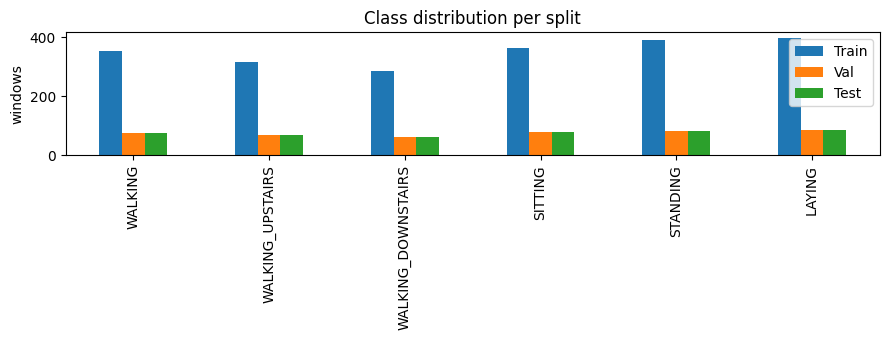

In [2]:
DATA_URL = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
ROOT = "UCI HAR Dataset"

def download_har():
    if os.path.isdir(ROOT):
        return
    if not os.path.exists("har_outer.zip"):
        req = urllib.request.Request(DATA_URL, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req) as r, open("har_outer.zip", "wb") as f:
            f.write(r.read())
    with zipfile.ZipFile("har_outer.zip") as z:
        z.extractall("har_tmp")
    for p in glob.glob("har_tmp/**/*.zip", recursive=True):      # the archive contains a nested zip
        with zipfile.ZipFile(p) as z:
            z.extractall(".")
    if not os.path.isdir(ROOT):
        cand = glob.glob("har_tmp/**/UCI HAR Dataset", recursive=True)
        if cand:
            shutil.move(cand[0], ROOT)
    assert os.path.isdir(ROOT), "Could not find 'UCI HAR Dataset'. Download it manually from the UCI link and upload it."

def load_split(split):
    chans = [pd.read_csv(f"{ROOT}/{split}/Inertial Signals/{s}_{split}.txt", sep=r"\s+", header=None).values
             for s in SIGNALS]
    X = np.stack(chans, axis=-1).astype("float32")                # (N,128,9)
    y = pd.read_csv(f"{ROOT}/{split}/y_{split}.txt", header=None).values.ravel().astype(int) - 1
    return X, y

download_har()
Xa, ya = load_split("train")
Xb, yb = load_split("test")
X_all = np.concatenate([Xa, Xb]); y_all = np.concatenate([ya, yb])
print("Pooled raw data:", X_all.shape, "labels:", y_all.shape)

# ---- stratified subset (all six classes preserved, ~balanced) ----
if N_TOTAL is not None and N_TOTAL < len(X_all):
    X_all, _, y_all, _ = train_test_split(X_all, y_all, train_size=N_TOTAL, stratify=y_all, random_state=SEED)

# ---- 70 / 15 / 15 stratified split ----
X_train_raw, X_tmp, y_train, y_tmp = train_test_split(X_all, y_all, test_size=0.30, stratify=y_all, random_state=SEED)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)

# ---- normalisation with TRAIN statistics only (per channel) ----
mu  = X_train_raw.mean(axis=(0, 1), keepdims=True)
std = X_train_raw.std(axis=(0, 1), keepdims=True) + 1e-8
X_train = ((X_train_raw - mu) / std).astype("float32")
X_val   = ((X_val_raw   - mu) / std).astype("float32")
X_test  = ((X_test_raw  - mu) / std).astype("float32")

print("\nInput tensor shape:")
print(f"Training   : {X_train.shape}")
print(f"Validation : {X_val.shape}")
print(f"Testing    : {X_test.shape}")
print("Number of classes:", len(CLASSES))
print("Number of features per time step:", X_train.shape[2])
print("Sequence length:", X_train.shape[1])

# ---- verify class distribution ----
dist = pd.DataFrame({"Train": np.bincount(y_train, minlength=6),
                     "Val":   np.bincount(y_val, minlength=6),
                     "Test":  np.bincount(y_test, minlength=6)}, index=CLASSES)
display(dist)
dist.plot(kind="bar", figsize=(9, 3.5), title="Class distribution per split"); plt.ylabel("windows"); plt.tight_layout()
save_fig("class_distribution"); plt.show()

## 6. Temporal Data Visualisation – Plot 1
Sensor value vs. time step (1–128) for three channels, one representative window from **each of the six** activity classes.

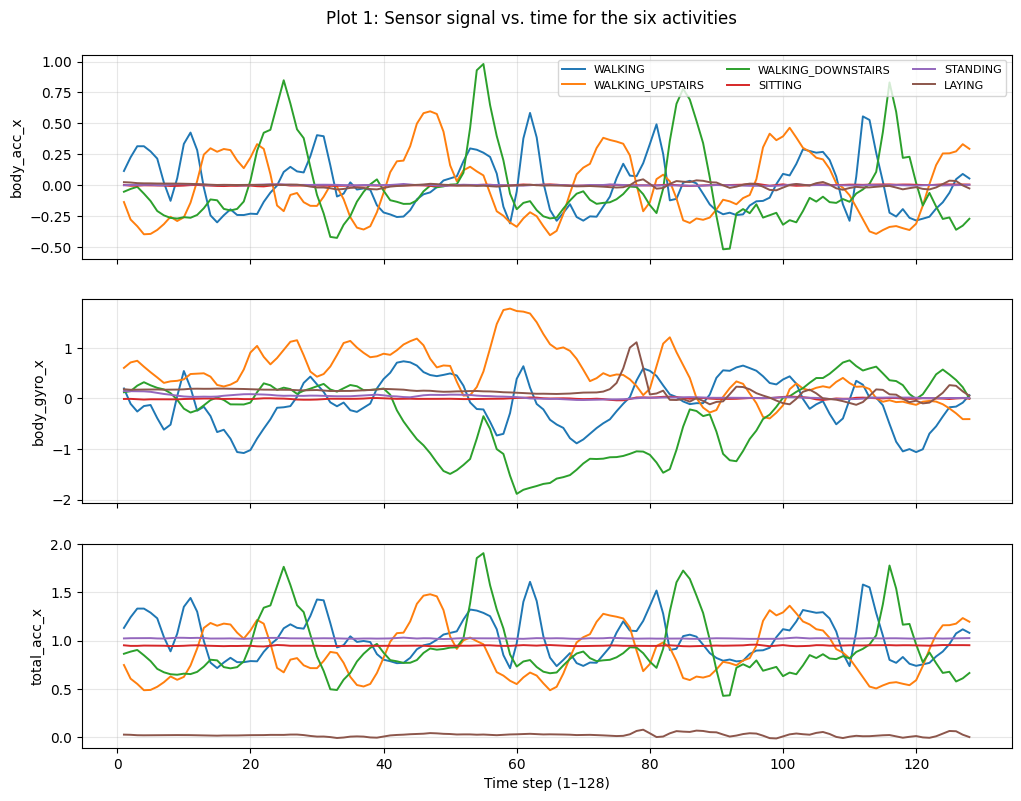

,mean temporal std (body_acc xyz),mean temporal std (body_gyro xyz),mean total_acc_x
class,,,
WALKING,0.1749,0.4274,0.9969
WALKING_UPSTAIRS,0.1907,0.4446,0.9537
WALKING_DOWNSTAIRS,0.2277,0.4844,0.9949
SITTING,0.0102,0.0212,0.9558
STANDING,0.0110,0.0338,1.0018
LAYING,0.0116,0.0246,0.0654



--- Inference (Plot 1) ---
1. Pattern: dynamic activities (WALKING_DOWNSTAIRS, WALKING_UPSTAIRS, WALKING) show large periodic oscillations; static ones (LAYING, STANDING, SITTING) are nearly flat lines.
2. Similar patterns: the three WALKING variants resemble each other; SITTING and STANDING resemble each other;
   LAYING is separable through the gravity (total_acc) offset, which changes with body orientation.
3. Order matters: the same set of values in a different order is a different motion (a gait cycle is a *sequence*);
   shuffling time steps destroys periodicity, so models must respect temporal order.


In [3]:
show_ch = {"body_acc_x": 0, "body_gyro_x": 3, "total_acc_x": 6}
t = np.arange(1, 129)
fig, axes = plt.subplots(len(show_ch), 1, figsize=(12, 9), sharex=True)
for ax, (cname, c) in zip(axes, show_ch.items()):
    for k, cls in enumerate(CLASSES):
        i = np.where(y_train == k)[0][0]
        ax.plot(t, X_train_raw[i, :, c], label=cls, lw=1.4)
    ax.set_ylabel(cname); ax.grid(alpha=.3)
axes[0].legend(ncol=3, fontsize=8, loc="upper right")
axes[-1].set_xlabel("Time step (1–128)")
fig.suptitle("Plot 1: Sensor signal vs. time for the six activities", y=0.93)
save_fig("plot1_signals"); plt.show()

# ---- data-driven support for the inference ----
rows = []
for k, cls in enumerate(CLASSES):
    Xk = X_train_raw[y_train == k]
    rows.append({"class": cls,
                 "mean temporal std (body_acc xyz)":  Xk[:, :, 0:3].std(axis=1).mean(),
                 "mean temporal std (body_gyro xyz)": Xk[:, :, 3:6].std(axis=1).mean(),
                 "mean total_acc_x": Xk[:, :, 6].mean()})
stats = pd.DataFrame(rows).set_index("class"); display(stats.round(4))
dyn = stats["mean temporal std (body_acc xyz)"].sort_values(ascending=False)
print("\n--- Inference (Plot 1) ---")
print("1. Pattern: dynamic activities (%s) show large periodic oscillations; static ones (%s) are nearly flat lines." %
      (", ".join(dyn.index[:3]), ", ".join(dyn.index[3:])))
print("2. Similar patterns: the three WALKING variants resemble each other; SITTING and STANDING resemble each other;")
print("   LAYING is separable through the gravity (total_acc) offset, which changes with body orientation.")
print("3. Order matters: the same set of values in a different order is a different motion (a gait cycle is a *sequence*);")
print("   shuffling time steps destroys periodicity, so models must respect temporal order.")

## 7–8. Vanilla RNN, Backpropagation Through Time and the Numerical Exercise
$h_t=\tanh(W_x x_t + W_h h_{t-1}+b_h)$, with the same weights re-used at each step.
BPTT unrolls the RNN and back-propagates through the T copies:
$\frac{\partial L}{\partial h_1}=\frac{\partial L}{\partial h_T}\prod_{t=2}^{T}\frac{\partial h_t}{\partial h_{t-1}},\quad \frac{\partial h_t}{\partial h_{t-1}}=\mathrm{diag}(1-h_t^2)\,W_h$
Norm < 1 repeatedly → **vanishing** gradients; norm > 1 repeatedly → **exploding** gradients.

In [4]:
# ---------- Numerical exercise: manual step-by-step vs. program vs. Keras ----------
x = [0.5, 0.7, 0.2]; Wx, Wh, b = 0.5, 0.8, 0.1; h_prev = 0.0
manual = []
print("h_t = tanh(Wx*x_t + Wh*h_(t-1) + b)\n")
for step, xt in enumerate(x, 1):
    pre = Wx * xt + Wh * h_prev + b
    h_t = np.tanh(pre)
    print(f"t={step}: pre = {Wx}*{xt} + {Wh}*{h_prev:.4f} + {b} = {pre:.4f}   ->  h{step} = tanh({pre:.4f}) = {h_t:.4f}")
    manual.append(h_t); h_prev = h_t

# same computation with a Keras SimpleRNN whose weights are set by hand
rnn1 = keras.Sequential([keras.Input((3, 1)), layers.SimpleRNN(1, activation="tanh", return_sequences=True)])
rnn1.layers[0].set_weights([np.array([[Wx]]), np.array([[Wh]]), np.array([b])])
keras_out = rnn1.predict(np.array(x, dtype="float32").reshape(1, 3, 1), verbose=0)[0, :, 0]
cmp_df = pd.DataFrame({"Manual / NumPy": manual, "Keras SimpleRNN": keras_out,
                       "abs diff": np.abs(np.array(manual) - keras_out)}, index=["h1", "h2", "h3"])
display(cmp_df.round(6))
print("Match:", np.allclose(manual, keras_out, atol=1e-6))

h_t = tanh(Wx*x_t + Wh*h_(t-1) + b)

t=1: pre = 0.5*0.5 + 0.8*0.0000 + 0.1 = 0.3500   ->  h1 = tanh(0.3500) = 0.3364
t=2: pre = 0.5*0.7 + 0.8*0.3364 + 0.1 = 0.7191   ->  h2 = tanh(0.7191) = 0.6164
t=3: pre = 0.5*0.2 + 0.8*0.6164 + 0.1 = 0.6931   ->  h3 = tanh(0.6931) = 0.6000


,Manual / NumPy,Keras SimpleRNN,abs diff
h1,0.336376,0.336376,0.0
h2,0.616352,0.616352,0.0
h3,0.599958,0.599958,0.0


Match: True


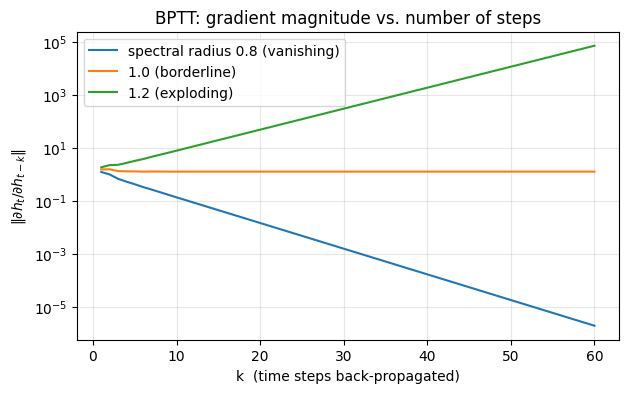

Vanishing: norm -> 0 so early time steps receive no learning signal (long-term dependencies lost).
Exploding: norm -> very large so training becomes unstable (mitigation: gradient clipping).


In [5]:
# ---------- Vanishing / exploding gradient illustration ----------
# ||dh_T/dh_0|| ~ ||prod_t diag(1-h_t^2) W_h||.  Best case for tanh (derivative = 1) -> ||W_h^k||.
def jacobian_norms(spectral_radius, steps=60, n=16, seed=0):
    rng = np.random.default_rng(seed)
    W = rng.normal(size=(n, n)); W = W / np.max(np.abs(np.linalg.eigvals(W))) * spectral_radius
    J = np.eye(n); out = []
    for _ in range(steps):
        J = W @ J; out.append(np.linalg.norm(J, 2))
    return out

plt.figure(figsize=(7, 4))
for rho, lab in [(0.8, "spectral radius 0.8 (vanishing)"), (1.0, "1.0 (borderline)"), (1.2, "1.2 (exploding)")]:
    plt.semilogy(range(1, 61), jacobian_norms(rho), label=lab)
plt.xlabel("k  (time steps back-propagated)"); plt.ylabel(r"$\|\partial h_t/\partial h_{t-k}\|$")
plt.title("BPTT: gradient magnitude vs. number of steps"); plt.legend(); plt.grid(alpha=.3)
save_fig("bptt_gradient_demo"); plt.show()
print("Vanishing: norm -> 0 so early time steps receive no learning signal (long-term dependencies lost).")
print("Exploding: norm -> very large so training becomes unstable (mitigation: gradient clipping).")

## 9–12. RNN, LSTM and GRU Implementation
Identical pipeline for all three – **only the recurrent layer changes**:
`Input(128×9) → {SimpleRNN | LSTM | GRU}(32) → Dropout(0.2) → Dense(16, ReLU) → Dense(6, Softmax)`
Adam (1e-3), batch 32, 30 epochs, sparse categorical cross-entropy.

**Gate comparison:** RNN – hidden state only · LSTM – hidden + cell state, forget/input/output gates (4 weight blocks) · GRU – hidden state only, update + reset gates (3 weight blocks).

In [6]:
RNN_LAYER = {"rnn": layers.SimpleRNN, "lstm": layers.LSTM, "gru": layers.GRU}
PRETTY = {"rnn": "RNN", "lstm": "LSTM", "gru": "GRU"}

def build_model(cell="rnn", units=UNITS, T=128, F=9, n_classes=6, n_layers=1, bidirectional=False, dropout=DROPOUT):
    inp = keras.Input((T, F)); x = inp
    for i in range(n_layers):
        layer = RNN_LAYER[cell](units, return_sequences=(i < n_layers - 1))
        if bidirectional:
            layer = layers.Bidirectional(layer)
        x = layer(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(16, activation="relu")(x)
    out = layers.Dense(n_classes, activation="softmax")(x)
    m = keras.Model(inp, out, name=f"{cell}{'_bi' if bidirectional else ''}_{n_layers}L_{units}u_T{T}")
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=LR),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

def n_trainable(m):
    return int(sum(np.prod(w.shape) for w in m.trainable_weights))

class Every(keras.callbacks.Callback):
    def __init__(self, k=10): super().__init__(); self.k = k
    def on_epoch_end(self, epoch, logs=None):
        if epoch == 0 or (epoch + 1) % self.k == 0:
            print(f"   epoch {epoch+1:>3} | loss {logs['loss']:.4f} acc {logs['accuracy']:.4f} | "
                  f"val_loss {logs['val_loss']:.4f} val_acc {logs['val_accuracy']:.4f}")

def train_eval(cell, data, epochs=EPOCHS, **kw):
    Xtr, ytr, Xva, yva, Xte, yte = data
    set_seed()
    m = build_model(cell, T=Xtr.shape[1], **kw)
    t0 = time.perf_counter()
    h = m.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=epochs, batch_size=BATCH, verbose=0, callbacks=[Every()])
    train_time = time.perf_counter() - t0
    pred = m.predict(Xte, verbose=0).argmax(1)
    p, r, f, _ = precision_recall_fscore_support(yte, pred, average="macro", zero_division=0)
    return dict(model=m, hist=h.history, pred=pred, acc=100 * accuracy_score(yte, pred),
                prec=100 * p, rec=100 * r, f1=100 * f, params=n_trainable(m), time=train_time)

DATA = (X_train, y_train, X_val, y_val, X_test, y_test)

for c in ["rnn", "lstm", "gru"]:
    print("=" * 30, PRETTY[c], "=" * 30)
    build_model(c).summary()

============================== RNN ==============================


Model: "rnn_1L_32u_T128"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,974 (7.71 KB)

 Trainable params: 1,974 (7.71 KB)

...

Model: "gru_1L_32u_T128"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,758 (18.59 KB)

 Trainable params: 4,758 (18.59 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
R = {}
for c in ["rnn", "lstm", "gru"]:
    print(f"\n>>> Training {PRETTY[c]}")
    R[c] = train_eval(c, DATA)
    print(f"   done in {R[c]['time']:.1f}s | test acc {R[c]['acc']:.2f}% | macro-F1 {R[c]['f1']:.2f}%")


>>> Training RNN
   epoch   1 | loss 1.5387 acc 0.4114 | val_loss 1.2756 val_acc 0.5156
   epoch  10 | loss 0.6652 acc 0.6724 | val_loss 0.6253 val_acc 0.6800
   epoch  20 | loss 0.5550 acc 0.7590 | val_loss 0.5048 val_acc 0.7778
   epoch  30 | loss 0.4979 acc 0.8195 | val_loss 0.4604 val_acc 0.8200
   done in 48.7s | test acc 81.11% | macro-F1 80.43%

>>> Training LSTM
   epoch   1 | loss 1.5798 acc 0.3648 | val_loss 1.3526 val_acc 0.4133
   epoch  10 | loss 0.5179 acc 0.8214 | val_loss 0.5037 val_acc 0.8133
   epoch  20 | loss 0.2128 acc 0.9124 | val_loss 0.2428 val_acc 0.9111
   epoch  30 | loss 0.2237 acc 0.9181 | val_loss 0.2399 val_acc 0.9089
   done in 96.3s | test acc 90.89% | macro-F1 91.13%

>>> Training GRU
   epoch   1 | loss 1.5943 acc 0.3710 | val_loss 1.3990 val_acc 0.5156
   epoch  10 | loss 0.2948 acc 0.9052 | val_loss 0.2265 val_acc 0.9356
   epoch  20 | loss 0.1465 acc 0.9452 | val_loss 0.1194 val_acc 0.9622
   epoch  30 | loss 0.1285 acc 0.9533 | val_loss 0.1160 va

## 13. Required Training Plots (Plots 2 and 3)

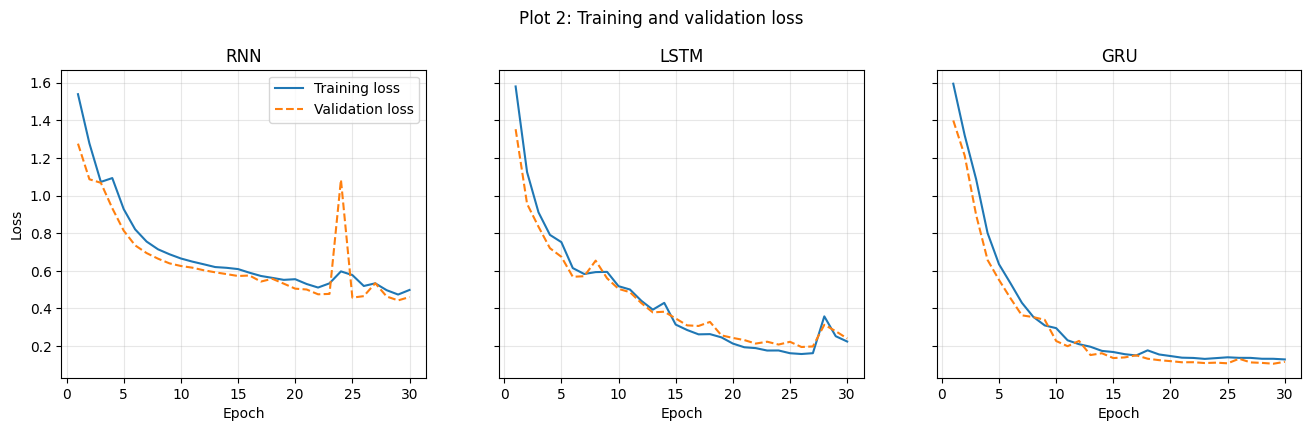

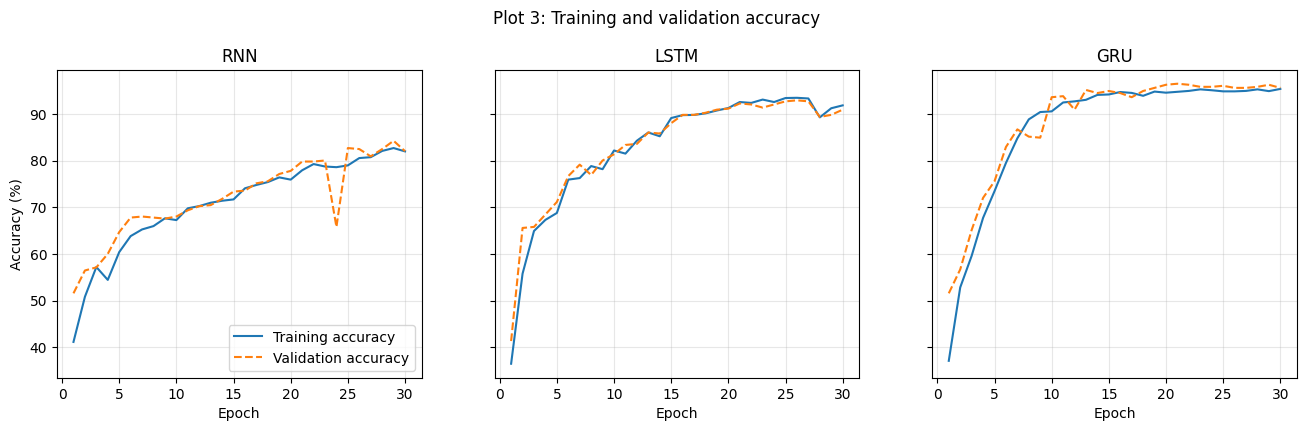

--- Inference (convergence, over/underfitting, generalisation gap) ---
[RNN] final train/val loss 0.498/0.460 | final train/val acc 82.0/82.0% | generalisation gap -0.0 pts
      best val-loss epoch = 29; first epoch with val acc >= 90%: None; convergence: still improving / noisy at the end
      Verdict: good fit (small generalisation gap)

[LSTM] final train/val loss 0.224/0.240 | final train/val acc 91.8/90.9% | generalisation gap +0.9 pts
      best val-loss epoch = 26; first epoch with val acc >= 90%: 18; convergence: still improving / noisy at the end
      Verdict: signs of OVERFITTING (training >> validation / validation loss rising)

[GRU] final train/val loss 0.129/0.116 | final train/val acc 95.3/95.6% | generalisation gap -0.2 pts
      best val-loss epoch = 29; first epoch with val acc >= 90%: 10; convergence: converged (loss curve flat over the last epochs)
      Verdict: good fit (small generalisation gap)



In [8]:
COLORS = {"rnn": "tab:red", "lstm": "tab:blue", "gru": "tab:green"}

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, c in zip(axes, ["rnn", "lstm", "gru"]):
    h = R[c]["hist"]; ep = np.arange(1, len(h["loss"]) + 1)
    ax.plot(ep, h["loss"], label="Training loss"); ax.plot(ep, h["val_loss"], label="Validation loss", ls="--")
    ax.set_title(f"{PRETTY[c]}"); ax.set_xlabel("Epoch"); ax.grid(alpha=.3)
axes[0].set_ylabel("Loss"); axes[0].legend()
fig.suptitle("Plot 2: Training and validation loss", y=1.03); save_fig("plot2_loss"); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, c in zip(axes, ["rnn", "lstm", "gru"]):
    h = R[c]["hist"]; ep = np.arange(1, len(h["loss"]) + 1)
    ax.plot(ep, 100 * np.array(h["accuracy"]), label="Training accuracy")
    ax.plot(ep, 100 * np.array(h["val_accuracy"]), label="Validation accuracy", ls="--")
    ax.set_title(f"{PRETTY[c]}"); ax.set_xlabel("Epoch"); ax.grid(alpha=.3)
axes[0].set_ylabel("Accuracy (%)"); axes[0].legend(loc="lower right")
fig.suptitle("Plot 3: Training and validation accuracy", y=1.03); save_fig("plot3_accuracy"); plt.show()

# ---------------- data-driven convergence / over-/under-fitting inference ----------------
def diagnose(name, h):
    tl, vl = np.array(h["loss"]), np.array(h["val_loss"])
    ta, va = 100 * np.array(h["accuracy"]), 100 * np.array(h["val_accuracy"])
    best_ep = int(vl.argmin()) + 1
    gap = ta[-1] - va[-1]
    recent = abs(tl[-5:].mean() - tl[-10:-5].mean())
    reach90 = next((i + 1 for i, a in enumerate(va) if a >= 90), None)
    val_rise = vl[-1] - vl.min()
    if ta[-1] < 70:                              verdict = "UNDERFITTING (training accuracy is still low)"
    elif gap > 5 or val_rise > 0.15 * vl.min():  verdict = "signs of OVERFITTING (training >> validation / validation loss rising)"
    else:                                        verdict = "good fit (small generalisation gap)"
    conv = "converged (loss curve flat over the last epochs)" if recent < 0.02 else "still improving / noisy at the end"
    print(f"[{name}] final train/val loss {tl[-1]:.3f}/{vl[-1]:.3f} | final train/val acc {ta[-1]:.1f}/{va[-1]:.1f}% | "
          f"generalisation gap {gap:+.1f} pts")
    print(f"      best val-loss epoch = {best_ep}; first epoch with val acc >= 90%: {reach90}; convergence: {conv}")
    print(f"      Verdict: {verdict}\n")

print("--- Inference (convergence, over/underfitting, generalisation gap) ---")
for c in ["rnn", "lstm", "gru"]:
    diagnose(PRETTY[c], R[c]["hist"])

## 14. Performance Evaluation on the Independent Test Set
Macro-averaged precision / recall / F1, parameter count and training time.

In [9]:
res = pd.DataFrame({PRETTY[c]: {"Accuracy (%)": R[c]["acc"], "Macro Precision (%)": R[c]["prec"],
                                "Macro Recall (%)": R[c]["rec"], "Macro F1 (%)": R[c]["f1"],
                                "Parameters": R[c]["params"], "Training Time (s)": R[c]["time"]}
                    for c in ["rnn", "lstm", "gru"]})
display(res.round(2))
res.round(4).to_csv("table_metrics_har.csv")

,RNN,LSTM,GRU
Accuracy (%),81.11,90.89,94.89
Macro Precision (%),82.47,91.54,95.37
Macro Recall (%),80.30,91.11,95.14
Macro F1 (%),80.43,91.13,95.18
Parameters,1974.00,6006.00,4758.00
Training Time (s),48.68,96.26,144.64


## 15. Confusion Matrix Analysis – Plot 4

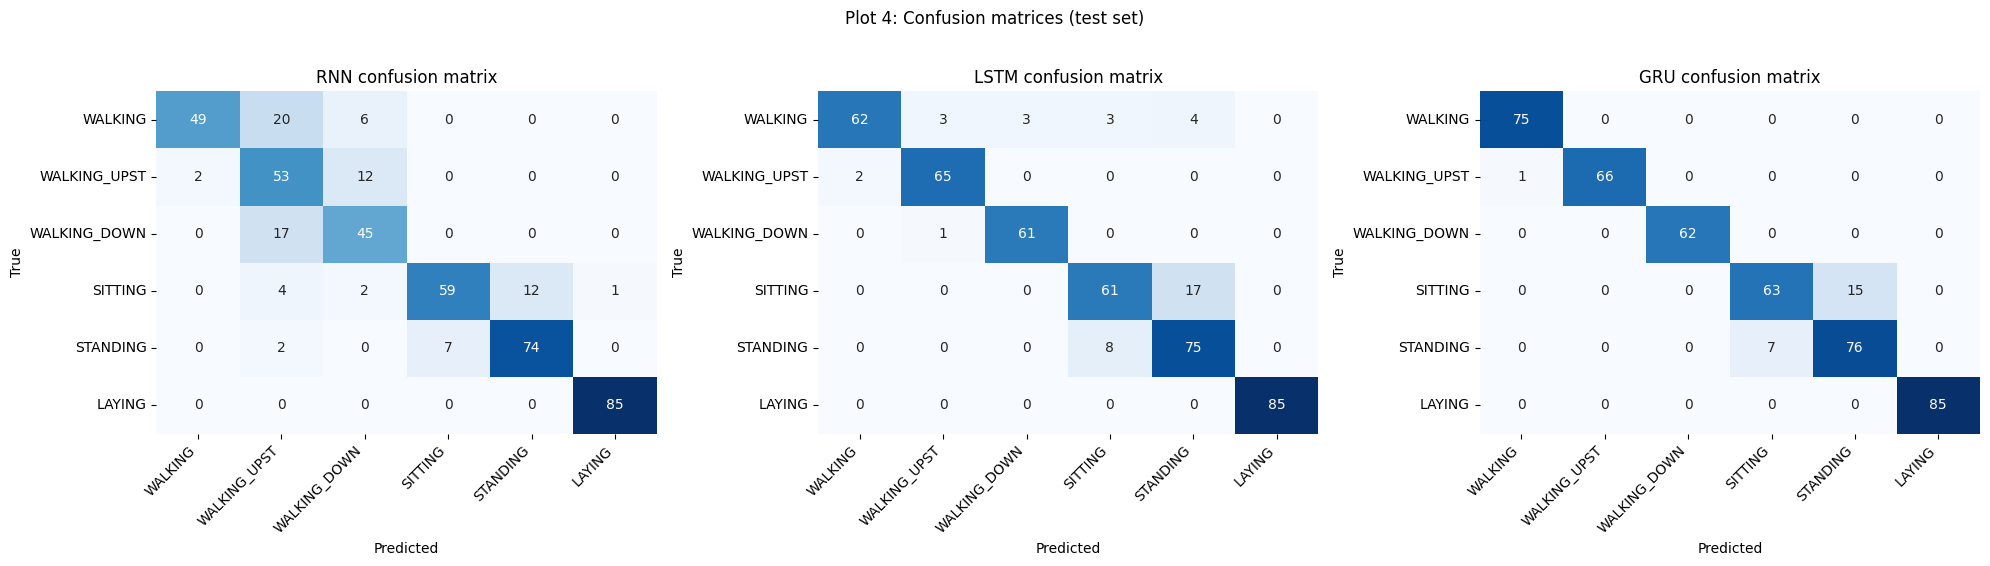

--- Inference (activity-wise errors) ---
[RNN]
   highest recognition rate : LAYING (100.0%)
   lowest recognition rate  : WALKING (65.3%)
   most misclassifications  : WALKING (26 windows)
   most confused pairs (true -> predicted): WALKING -> WALKING_UPSTAIRS (20); WALKING_DOWNSTAIRS -> WALKING_UPSTAIRS (17); SITTING -> STANDING (12)
[LSTM]
   highest recognition rate : LAYING (100.0%)
   lowest recognition rate  : SITTING (78.2%)
   most misclassifications  : SITTING (17 windows)
   most confused pairs (true -> predicted): SITTING -> STANDING (17); STANDING -> SITTING (8); WALKING -> STANDING (4)
[GRU]
   highest recognition rate : WALKING (100.0%)
   lowest recognition rate  : SITTING (80.8%)
   most misclassifications  : SITTING (15 windows)
   most confused pairs (true -> predicted): SITTING -> STANDING (15); STANDING -> SITTING (7); WALKING_UPSTAIRS -> WALKING (1)

Confused in ALL three models: ['SITTING <-> STANDING']
Errors consistent across models? largely yes


In [10]:
def analyze_cm(name, cm, class_names, top_k=3):
    recall = cm.diagonal() / np.maximum(cm.sum(1), 1)
    mis = cm.sum(1) - cm.diagonal()
    off = cm.copy(); np.fill_diagonal(off, 0)
    n = len(class_names)
    pairs = sorted([(off[i, j], i, j) for i in range(n) for j in range(n) if i != j], reverse=True)[:top_k]
    print(f"[{name}]")
    print(f"   highest recognition rate : {class_names[recall.argmax()]} ({100*recall.max():.1f}%)")
    print(f"   lowest recognition rate  : {class_names[recall.argmin()]} ({100*recall.min():.1f}%)")
    print(f"   most misclassifications  : {class_names[mis.argmax()]} ({mis.max()} windows)")
    print("   most confused pairs (true -> predicted): " +
          "; ".join(f"{class_names[i]} -> {class_names[j]} ({v})" for v, i, j in pairs if v > 0))
    return {frozenset((i, j)) for v, i, j in pairs if v > 0}

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
cms, pair_sets = {}, {}
for ax, c in zip(axes, ["rnn", "lstm", "gru"]):
    cm = confusion_matrix(y_test, R[c]["pred"], labels=range(6)); cms[c] = cm
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=[s[:12] for s in CLASSES], yticklabels=[s[:12] for s in CLASSES])
    ax.set_title(f"{PRETTY[c]} confusion matrix"); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
fig.suptitle("Plot 4: Confusion matrices (test set)", y=1.02); plt.tight_layout(); save_fig("plot4_confusion"); plt.show()

print("--- Inference (activity-wise errors) ---")
for c in ["rnn", "lstm", "gru"]:
    pair_sets[c] = analyze_cm(PRETTY[c], cms[c], CLASSES)
common = set.intersection(*pair_sets.values())
print("\nConfused in ALL three models:", [f"{CLASSES[min(p)]} <-> {CLASSES[max(p)]}" for p in common] or "none of the top pairs are shared")
print("Errors consistent across models?", "largely yes" if len(common) > 0 else "no - error patterns differ between models")

## 16. RNN vs. LSTM vs. GRU Comparison – Plot 5

,RNN,LSTM,GRU
Hidden state,Yes,Yes,Yes
Cell state,No,Yes,No
Forget gate,No,Yes,No
Input gate,No,Yes,No
Output gate,No,Yes,No
Update gate,No,No,Yes
Reset gate,No,No,Yes
Parameters,"1,974","6,006","4,758"
Training time (s),48.7,96.3,144.6
Test F1-score (%),80.43,91.13,95.18


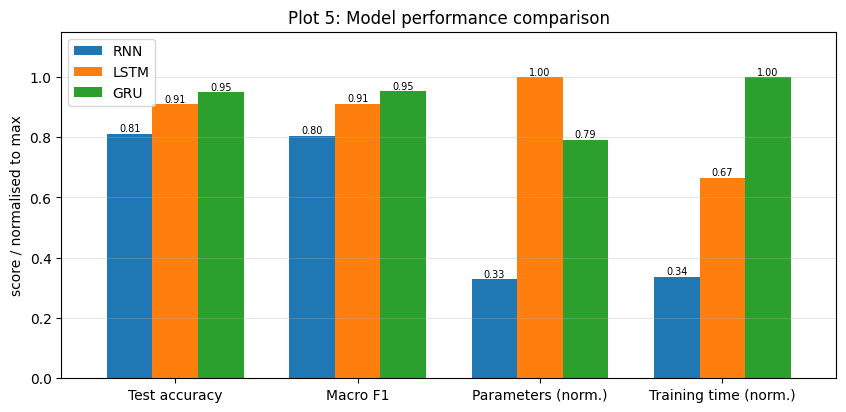

--- Inference (parameters, computation, trade-off) ---
Parameters: LSTM/RNN = 3.04x, GRU/RNN = 2.41x, GRU/LSTM = 0.79x
Training time: LSTM/RNN = 1.98x, GRU/RNN = 2.97x, GRU/LSTM = 1.50x
Best macro-F1: GRU (95.18%).
Trade-off: gated models (LSTM/GRU) add 3-4x recurrent weights (and cuDNN-friendly kernels) to gain a more stable gradient path;
the GRU usually reaches similar accuracy to the LSTM with ~25% fewer recurrent parameters.


In [11]:
comp = pd.DataFrame({
    "RNN":  ["Yes", "No",  "No",  "No",  "No",  "No",  "No"],
    "LSTM": ["Yes", "Yes", "Yes", "Yes", "Yes", "No",  "No"],
    "GRU":  ["Yes", "No",  "No",  "No",  "No",  "Yes", "Yes"]},
    index=["Hidden state", "Cell state", "Forget gate", "Input gate", "Output gate", "Update gate", "Reset gate"])
for name, key, fmt in [("Parameters", "params", "{:,}"), ("Training time (s)", "time", "{:.1f}"), ("Test F1-score (%)", "f1", "{:.2f}")]:
    comp.loc[name] = [fmt.format(R[c][key]) for c in ["rnn", "lstm", "gru"]]
display(comp)

# ---------- Plot 5 ----------
norm = pd.DataFrame({
    "Test accuracy":       res.loc["Accuracy (%)"] / 100,
    "Macro F1":            res.loc["Macro F1 (%)"] / 100,
    "Parameters (norm.)":  res.loc["Parameters"] / res.loc["Parameters"].max(),
    "Training time (norm.)": res.loc["Training Time (s)"] / res.loc["Training Time (s)"].max()})
ax = norm.T.plot(kind="bar", figsize=(10, 4.5), rot=0, width=.75)
ax.set_ylim(0, 1.15); ax.set_ylabel("score / normalised to max"); ax.grid(axis="y", alpha=.3)
for cont in ax.containers: ax.bar_label(cont, fmt="%.2f", fontsize=7)
plt.title("Plot 5: Model performance comparison"); save_fig("plot5_comparison"); plt.show()

print("--- Inference (parameters, computation, trade-off) ---")
p, tm = res.loc["Parameters"], res.loc["Training Time (s)"]
print(f"Parameters: LSTM/RNN = {p['LSTM']/p['RNN']:.2f}x, GRU/RNN = {p['GRU']/p['RNN']:.2f}x, GRU/LSTM = {p['GRU']/p['LSTM']:.2f}x")
print(f"Training time: LSTM/RNN = {tm['LSTM']/tm['RNN']:.2f}x, GRU/RNN = {tm['GRU']/tm['RNN']:.2f}x, GRU/LSTM = {tm['GRU']/tm['LSTM']:.2f}x")
best = res.loc["Macro F1 (%)"].idxmax()
print(f"Best macro-F1: {best} ({res.loc['Macro F1 (%)'].max():.2f}%).")
print("Trade-off: gated models (LSTM/GRU) add 3-4x recurrent weights (and cuDNN-friendly kernels) to gain a more stable gradient path;")
print("the GRU usually reaches similar accuracy to the LSTM with ~25% fewer recurrent parameters.")

## 17. Effect of Sequence Length – Plot 6
The same experiment is repeated with `T ∈ {32, 64, 128}`. Sequences are **truncated consistently to the first T time steps** (same normalisation, same seed, same hyper-parameters).


>>> RNN with T = 32
   epoch   1 | loss 1.5401 acc 0.4167 | val_loss 1.2504 val_acc 0.5489
   epoch  10 | loss 0.6400 acc 0.7110 | val_loss 0.6435 val_acc 0.6911
   epoch  20 | loss 0.5608 acc 0.7619 | val_loss 0.5867 val_acc 0.7489
   epoch  30 | loss 0.5390 acc 0.7743 | val_loss 0.5501 val_acc 0.7733
   test macro-F1 77.47% | time 22.9s

>>> LSTM with T = 32
   epoch   1 | loss 1.5828 acc 0.3648 | val_loss 1.3626 val_acc 0.4156
   epoch  10 | loss 0.3567 acc 0.8657 | val_loss 0.3557 val_acc 0.8600
   epoch  20 | loss 0.1655 acc 0.9352 | val_loss 0.2443 val_acc 0.9133
   epoch  30 | loss 0.1287 acc 0.9452 | val_loss 0.2111 val_acc 0.9289
   test macro-F1 91.11% | time 35.1s

>>> GRU with T = 32
   epoch   1 | loss 1.5934 acc 0.3686 | val_loss 1.3876 val_acc 0.5222
   epoch  10 | loss 0.3380 acc 0.8786 | val_loss 0.3524 val_acc 0.8667
   epoch  20 | loss 0.1663 acc 0.9395 | val_loss 0.2009 val_acc 0.9178
   epoch  30 | loss 0.1337 acc 0.9490 | val_loss 0.1757 val_acc 0.9222
   test ma

,RNN F1,LSTM F1,GRU F1
Sequence Length,,,
32,77.47,91.11,92.91
64,74.53,94.68,94.37
128,80.43,91.13,95.18


,RNN time (s),LSTM time (s),GRU time (s)
Sequence Length,,,
32,22.9,35.1,35.0
64,29.7,51.4,60.5
128,48.7,96.3,144.6


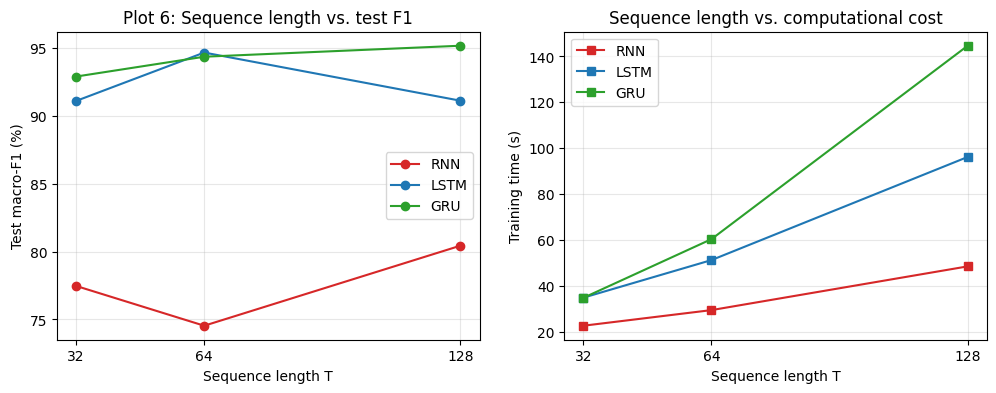

--- Inference (effect of sequence length) ---
RNN: F1 changes by +2.97 pts from T=32 to T=128; training time x2.13
LSTM: F1 changes by +0.02 pts from T=32 to T=128; training time x2.74
GRU: F1 changes by +2.27 pts from T=32 to T=128; training time x4.13
More time steps = more temporal context (a full gait cycle, posture offset), which usually raises F1, but cost grows ~linearly with T
and the plain RNN has the hardest time exploiting long context because of vanishing gradients.


In [12]:
SL = {}   # (cell, T) -> dict
for c in ["rnn", "lstm", "gru"]:
    SL[(c, 128)] = R[c]
for T in SEQ_LENS:
    if T == 128: continue
    dT = (X_train[:, :T], y_train, X_val[:, :T], y_val, X_test[:, :T], y_test)
    for c in ["rnn", "lstm", "gru"]:
        print(f"\n>>> {PRETTY[c]} with T = {T}")
        SL[(c, T)] = train_eval(c, dT)
        print(f"   test macro-F1 {SL[(c, T)]['f1']:.2f}% | time {SL[(c, T)]['time']:.1f}s")

f1_tab = pd.DataFrame({f"{PRETTY[c]} F1": {T: SL[(c, T)]["f1"] for T in SEQ_LENS} for c in ["rnn", "lstm", "gru"]})
f1_tab.index.name = "Sequence Length"; display(f1_tab.round(2))
time_tab = pd.DataFrame({f"{PRETTY[c]} time (s)": {T: SL[(c, T)]["time"] for T in SEQ_LENS} for c in ["rnn", "lstm", "gru"]})
time_tab.index.name = "Sequence Length"; display(time_tab.round(1))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for c in ["rnn", "lstm", "gru"]:
    ax[0].plot(SEQ_LENS, [SL[(c, T)]["f1"] for T in SEQ_LENS], marker="o", label=PRETTY[c], color=COLORS[c])
    ax[1].plot(SEQ_LENS, [SL[(c, T)]["time"] for T in SEQ_LENS], marker="s", label=PRETTY[c], color=COLORS[c])
ax[0].set_xlabel("Sequence length T"); ax[0].set_ylabel("Test macro-F1 (%)"); ax[0].set_title("Plot 6: Sequence length vs. test F1")
ax[1].set_xlabel("Sequence length T"); ax[1].set_ylabel("Training time (s)"); ax[1].set_title("Sequence length vs. computational cost")
for a in ax: a.set_xticks(SEQ_LENS); a.grid(alpha=.3); a.legend()
save_fig("plot6_seqlen"); plt.show()

print("--- Inference (effect of sequence length) ---")
for c in ["rnn", "lstm", "gru"]:
    d = SL[(c, 128)]["f1"] - SL[(c, 32)]["f1"]
    print(f"{PRETTY[c]}: F1 changes by {d:+.2f} pts from T=32 to T=128; training time x{SL[(c,128)]['time']/SL[(c,32)]['time']:.2f}")
print("More time steps = more temporal context (a full gait cycle, posture offset), which usually raises F1, but cost grows ~linearly with T")
print("and the plain RNN has the hardest time exploiting long context because of vanishing gradients.")

## 18–21. Video Understanding: Pretrained CNN (MobileNetV2) + LSTM/GRU on UCF101
Pipeline: `Video → 10 uniformly sampled frames (224×224×3) → frozen MobileNetV2 (global avg pool) → (10, D) → LSTM/GRU(32) → Dense → Softmax`

* 5 classes: **Basketball, Biking, WalkingWithDog, TennisSwing, JumpRope** (UCF101 has no plain "Running"/"Walking" class; `WalkingWithDog` is the closest to walking).
* Split **by video group** (`gXX` in the file name) – clips of the same group come from the same source video, so this avoids leakage: groups 1–7 test, 8–22 train, 23–25 validation.
* **Data source** (`VIDEO_SOURCE`):
  * `"official"` – downloads the full UCF101.rar (~6.5 GB, slow but exact) and extracts only the chosen classes;
  * `"hf_subset"` – small pre-cut UCF101 subset from Hugging Face (faster; classes are chosen automatically from what it contains);
  * `"local"` – you upload/mount videos named `v_<Class>_gXX_cYY.avi` into `LOCAL_VIDEO_DIR`.

In [13]:
import cv2
from tqdm.auto import tqdm

VIDEO_SOURCE    = "official"      # "official" | "hf_subset" | "local"
VIDEO_CLASSES   = ["Basketball", "Biking", "WalkingWithDog", "TennisSwing", "JumpRope"]
MAX_PER_CLASS   = 60
N_FRAMES        = 10
LOCAL_VIDEO_DIR = "/content/videos"
VIDEO_ROOT      = "ucf_videos"
UCF_URL = "https://www.crcv.ucf.edu/data/UCF101/UCF101.rar"
HF_URL  = "https://huggingface.co/datasets/sayakpaul/ucf101-subset/resolve/main/UCF101_subset.tar.gz"

def get_videos():
    global VIDEO_ROOT
    if VIDEO_SOURCE == "local":
        VIDEO_ROOT = LOCAL_VIDEO_DIR; return
    if glob.glob(f"{VIDEO_ROOT}/**/*.avi", recursive=True):
        return
    os.makedirs(VIDEO_ROOT, exist_ok=True)
    if VIDEO_SOURCE == "official":
        if not os.path.exists("UCF101.rar"):
            print("Downloading UCF101.rar (~6.5 GB) ... this can take several minutes")
            subprocess.run(["wget", "-q", "--no-check-certificate", "-O", "UCF101.rar", UCF_URL], check=True)
        subprocess.run("apt-get -qq install -y unrar > /dev/null 2>&1", shell=True)
        for c in VIDEO_CLASSES:
            print("extracting", c)
            subprocess.run(["unrar", "x", "-o+", "-inul", "UCF101.rar", f"UCF-101/{c}/*", VIDEO_ROOT + "/"], check=True)
    elif VIDEO_SOURCE == "hf_subset":
        subprocess.run(["wget", "-q", "-O", "UCF101_subset.tar.gz", HF_URL], check=True)
        subprocess.run(["tar", "xf", "UCF101_subset.tar.gz", "-C", VIDEO_ROOT], check=True)

get_videos()
pat = re.compile(r"v_(.+)_g(\d+)_c(\d+)\.(avi|mp4)$")
found = []
for p in glob.glob(f"{VIDEO_ROOT}/**/*.*", recursive=True):
    m = pat.search(os.path.basename(p))
    if m: found.append((p, m.group(1), int(m.group(2))))
found_counts = pd.Series([f[1] for f in found]).value_counts()
print("Classes found:", dict(found_counts))

sel_classes = [c for c in VIDEO_CLASSES if c in found_counts.index]
if len(sel_classes) < 3:                                    # fall back to the most frequent available classes
    sel_classes = list(found_counts.index[:5])
print("Selected classes:", sel_classes)

vids = []
for c in sel_classes:                                       # evenly spaced pick across groups, capped per class
    items = sorted([f for f in found if f[1] == c], key=lambda z: (z[2], z[0]))
    idx = np.linspace(0, len(items) - 1, min(MAX_PER_CLASS, len(items))).astype(int)
    vids += [items[i] for i in sorted(set(idx))]
print("Total videos used:", len(vids))

extracting Basketball
extracting Biking
extracting WalkingWithDog
extracting TennisSwing
extracting JumpRope
Classes found: {'TennisSwing': np.int64(166), 'JumpRope': np.int64(144), 'Basketball': np.int64(134), 'Biking': np.int64(134), 'WalkingWithDog': np.int64(123)}
Selected classes: ['Basketball', 'Biking', 'WalkingWithDog', 'TennisSwing', 'JumpRope']
Total videos used: 300


In [14]:
def sample_frames(path, n=N_FRAMES, size=224):
    cap = cv2.VideoCapture(path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    idxs = np.linspace(0, max(total - 1, 0), n).astype(int)     # 10 frames sampled uniformly
    frames = []
    for i in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(i)); ok, f = cap.read()
        if ok:
            f = cv2.resize(cv2.cvtColor(f, cv2.COLOR_BGR2RGB), (size, size))
        else:
            f = frames[-1] if frames else np.zeros((size, size, 3), np.uint8)
        frames.append(f)
    cap.release()
    return np.stack(frames)                                     # (10,224,224,3)

# frozen pretrained CNN, classification head removed, global average pooling -> D-dim vector per frame
cnn = keras.applications.MobileNetV2(include_top=False, weights="imagenet", pooling="avg", input_shape=(224, 224, 3))
cnn.trainable = False
D = cnn.output_shape[-1]
print("CNN feature dimension D =", D)

FEAT_FILE = "ucf_features.npz"
if os.path.exists(FEAT_FILE):
    z = np.load(FEAT_FILE, allow_pickle=True)
    if list(z["paths"]) == [v[0] for v in vids]:
        feats, sample_video_frames = z["feats"], z["demo_frames"]
        print("Loaded cached features")
    else:
        os.remove(FEAT_FILE)

if not os.path.exists(FEAT_FILE):
    feats, demo = [], None
    for k, (p, c, g) in enumerate(tqdm(vids, desc="Extracting CNN features")):
        fr = sample_frames(p)
        if demo is None: demo = fr.copy()
        x = keras.applications.mobilenet_v2.preprocess_input(fr.astype("float32"))
        feats.append(cnn.predict(x, verbose=0))                 # (10, D)
    feats = np.stack(feats).astype("float32"); sample_video_frames = demo
    np.savez_compressed(FEAT_FILE, feats=feats, paths=np.array([v[0] for v in vids]), demo_frames=sample_video_frames)

class_names_v = sel_classes
v_labels = np.array([class_names_v.index(v[1]) for v in vids])
v_groups = np.array([v[2] for v in vids])

# ---- group-wise split (fallback: stratified random) ----
split = np.array(["test" if g <= 7 else ("val" if g >= 23 else "train") for g in v_groups])
ok = all((split[v_labels == k] == s).any() for k in range(len(class_names_v)) for s in ["train", "val", "test"])
if not ok:
    print("Group split leaves a class empty in some split -> using stratified random 70/15/15 split instead")
    idx = np.arange(len(vids))
    tr, tmp = train_test_split(idx, test_size=0.30, stratify=v_labels, random_state=SEED)
    va, te = train_test_split(tmp, test_size=0.50, stratify=v_labels[tmp], random_state=SEED)
    split = np.empty(len(vids), dtype=object); split[tr] = "train"; split[va] = "val"; split[te] = "test"

Xv_tr, yv_tr = feats[split == "train"], v_labels[split == "train"]
Xv_va, yv_va = feats[split == "val"],   v_labels[split == "val"]
Xv_te, yv_te = feats[split == "test"],  v_labels[split == "test"]
te_paths = [vids[i][0] for i in np.where(split == "test")[0]]

print("\nCNN feature dimension D =", D)
print("Tensor supplied to the recurrent network per video: (10, %d)   ->  batch: (B, 10, %d)" % (D, D))
print("Train:", Xv_tr.shape, "| Val:", Xv_va.shape, "| Test:", Xv_te.shape)
print("Videos per class (train/val/test):")
display(pd.DataFrame({"train": np.bincount(yv_tr, minlength=len(class_names_v)),
                      "val": np.bincount(yv_va, minlength=len(class_names_v)),
                      "test": np.bincount(yv_te, minlength=len(class_names_v))}, index=class_names_v))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
CNN feature dimension D = 1280


Extracting CNN features:   0%|          | 0/300 [00:00<?, ?it/s]


CNN feature dimension D = 1280
Tensor supplied to the recurrent network per video: (10, 1280)   ->  batch: (B, 10, 1280)
Train: (178, 10, 1280) | Val: (37, 10, 1280) | Test: (85, 10, 1280)
Videos per class (train/val/test):


,train,val,test
Basketball,36,8,16
Biking,36,7,17
WalkingWithDog,35,7,18
TennisSwing,35,7,18
JumpRope,36,8,16


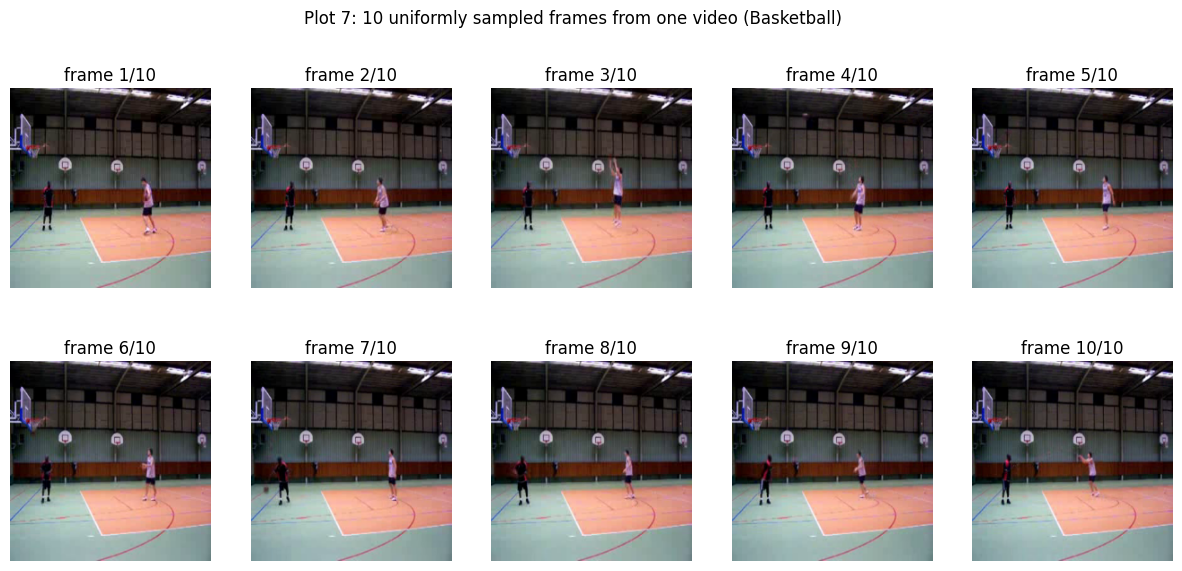

CNN (MobileNetV2): spatial information within each frame - edges, textures, shapes, objects (ball, bike, dog, racket, rope), scene/pose.
Recurrent net (LSTM/GRU): temporal information across frames - motion, order of appearance, how the scene changes over time.


In [15]:
# ---------------- Plot 7: sampled frames of one video ----------------
fig, axes = plt.subplots(2, 5, figsize=(15, 6.5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(sample_video_frames[i]); ax.set_title(f"frame {i+1}/10"); ax.axis("off")
fig.suptitle(f"Plot 7: 10 uniformly sampled frames from one video ({vids[0][1]})", y=0.98)
save_fig("plot7_video_frames"); plt.show()
print("CNN (MobileNetV2): spatial information within each frame - edges, textures, shapes, objects (ball, bike, dog, racket, rope), scene/pose.")
print("Recurrent net (LSTM/GRU): temporal information across frames - motion, order of appearance, how the scene changes over time.")

In [16]:
# ---------------- CNN-LSTM / CNN-GRU model ----------------
V_EPOCHS, V_BATCH = 40, 16
def build_video_model(cell, D, n_classes, T=N_FRAMES, units=32):
    inp = keras.Input((T, D))
    x = RNN_LAYER[cell](units)(inp)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(16, activation="relu")(x)
    out = layers.Dense(n_classes, activation="softmax")(x)
    m = keras.Model(inp, out, name=f"cnn_{cell}")
    m.compile(optimizer=keras.optimizers.Adam(LR), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

VR = {}
for c in ["lstm", "gru"]:
    print(f"\n>>> CNN-{PRETTY[c]}")
    set_seed(); m = build_video_model(c, D, len(class_names_v)); m.summary()
    t0 = time.perf_counter()
    h = m.fit(Xv_tr, yv_tr, validation_data=(Xv_va, yv_va), epochs=V_EPOCHS, batch_size=V_BATCH, verbose=0, callbacks=[Every()])
    tt = time.perf_counter() - t0
    probs = m.predict(Xv_te, verbose=0); pred = probs.argmax(1)
    p, r, f, _ = precision_recall_fscore_support(yv_te, pred, average="macro", zero_division=0)
    VR[c] = dict(model=m, hist=h.history, probs=probs, pred=pred, acc=100 * accuracy_score(yv_te, pred),
                 prec=100 * p, rec=100 * r, f1=100 * f, params=n_trainable(m), time=tt,
                 val_acc=100 * h.history["val_accuracy"][-1])
    print(f"   test acc {VR[c]['acc']:.2f}% | macro-F1 {VR[c]['f1']:.2f}% | params {VR[c]['params']:,} | time {tt:.1f}s")

v_sel = max(VR, key=lambda k: (VR[k]["val_acc"], VR[k]["f1"]))       # selected using VALIDATION only
print(f"\nSelected recurrent architecture (best final validation accuracy): CNN-{PRETTY[v_sel]}")
display(pd.DataFrame({f"CNN-{PRETTY[c]}": {"Accuracy (%)": VR[c]["acc"], "Macro Precision (%)": VR[c]["prec"],
                                           "Macro Recall (%)": VR[c]["rec"], "Macro F1 (%)": VR[c]["f1"],
                                           "Parameters": VR[c]["params"], "Training Time (s)": VR[c]["time"]}
                      for c in VR}).round(2))


>>> CNN-LSTM


Model: "cnn_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 10, 1280)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 32)             │       168,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,677 (658.89 KB)

 Trainable params: 168,677 (658.89 KB)

...

 Total params: 126,757 (495.14 KB)

 Trainable params: 126,757 (495.14 KB)

 Non-trainable params: 0 (0.00 B)

   epoch   1 | loss 1.5714 acc 0.2809 | val_loss 1.3125 val_acc 0.5676
   epoch  10 | loss 0.1715 acc 1.0000 | val_loss 0.3941 val_acc 0.8919
   epoch  20 | loss 0.0322 acc 1.0000 | val_loss 0.3186 val_acc 0.8919
   epoch  30 | loss 0.0131 acc 1.0000 | val_loss 0.3462 val_acc 0.9189
   epoch  40 | loss 0.0071 acc 1.0000 | val_loss 0.3529 val_acc 0.9189
   test acc 71.76% | macro-F1 71.63% | params 126,757 | time 12.9s

Selected recurrent architecture (best final validation accuracy): CNN-LSTM


,CNN-LSTM,CNN-GRU
Accuracy (%),74.12,71.76
Macro Precision (%),74.11,73.01
Macro Recall (%),74.17,71.95
Macro F1 (%),73.02,71.63
Parameters,168677.00,126757.00
Training Time (s),12.45,12.90


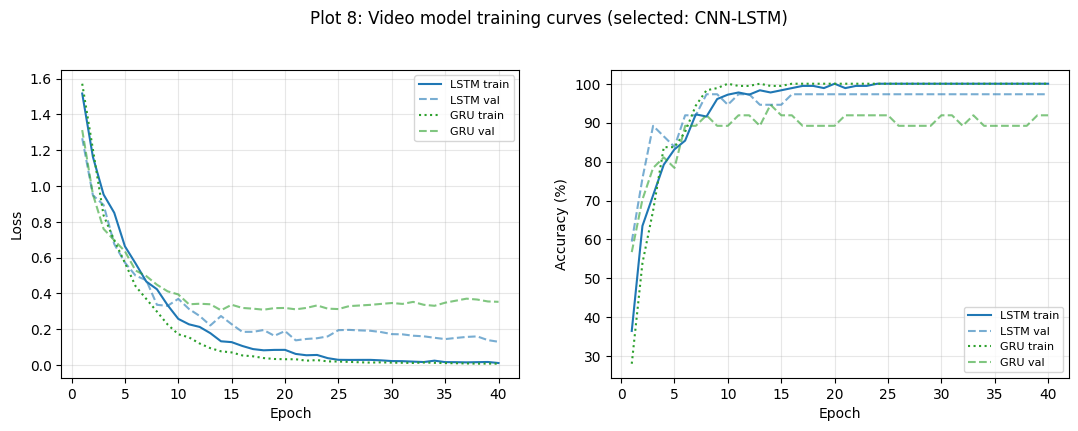

[CNN-LSTM] final train/val loss 0.011/0.130 | final train/val acc 100.0/97.3% | generalisation gap +2.7 pts
      best val-loss epoch = 40; first epoch with val acc >= 90%: 6; convergence: converged (loss curve flat over the last epochs)
      Verdict: good fit (small generalisation gap)



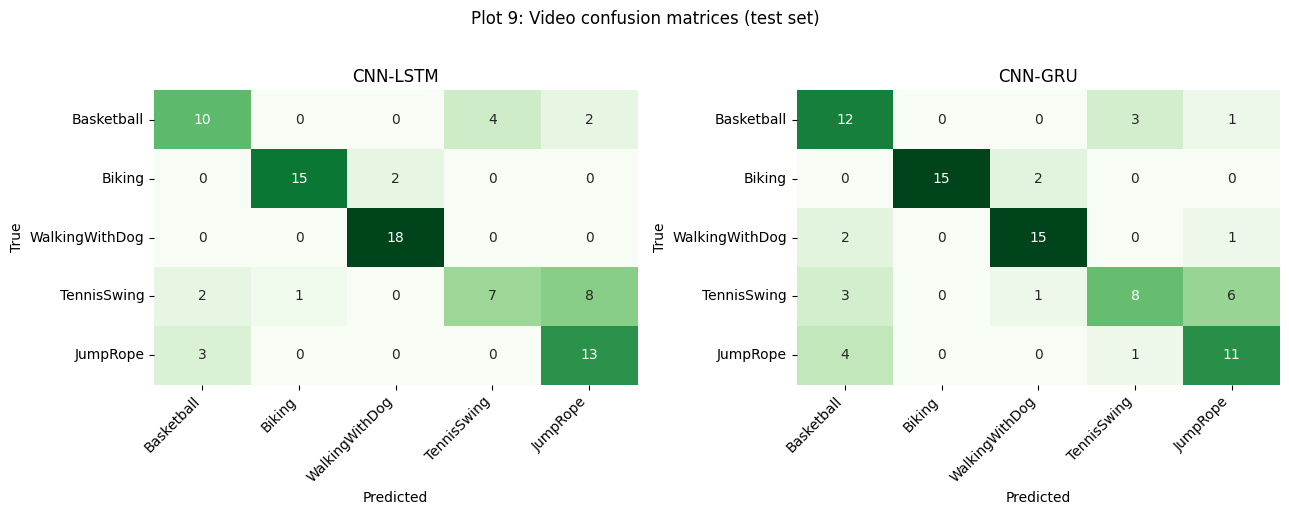

--- Inference (class-level recognition / temporal confusions) ---
[CNN-LSTM]
   highest recognition rate : WalkingWithDog (100.0%)
   lowest recognition rate  : TennisSwing (38.9%)
   most misclassifications  : TennisSwing (11 windows)
   most confused pairs (true -> predicted): TennisSwing -> JumpRope (8); Basketball -> TennisSwing (4); JumpRope -> Basketball (3)
[CNN-GRU]
   highest recognition rate : Biking (88.2%)
   lowest recognition rate  : TennisSwing (44.4%)
   most misclassifications  : TennisSwing (10 windows)
   most confused pairs (true -> predicted): TennisSwing -> JumpRope (6); JumpRope -> Basketball (4); TennisSwing -> Basketball (3)

Sample predictions (confidence = softmax probability from the trained CNN-LSTM):

  Video: v_TennisSwing_g01_c06.avi
    Predicted class : JumpRope
    Actual class    : TennisSwing
    Confidence      : 0.83

  Video: v_TennisSwing_g05_c03.avi
    Predicted class : Basketball
    Actual class    : TennisSwing
    Confidence      : 0.94

 

In [17]:
# ---------------- Plot 8: training / validation curves ----------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for c in VR:
    h = VR[c]["hist"]; ep = np.arange(1, len(h["loss"]) + 1)
    ls = "-" if c == v_sel else ":"
    axes[0].plot(ep, h["loss"], ls, color=COLORS[c], label=f"{PRETTY[c]} train"); axes[0].plot(ep, h["val_loss"], "--", color=COLORS[c], alpha=.6, label=f"{PRETTY[c]} val")
    axes[1].plot(ep, 100*np.array(h["accuracy"]), ls, color=COLORS[c], label=f"{PRETTY[c]} train"); axes[1].plot(ep, 100*np.array(h["val_accuracy"]), "--", color=COLORS[c], alpha=.6, label=f"{PRETTY[c]} val")
axes[0].set_ylabel("Loss"); axes[1].set_ylabel("Accuracy (%)")
for a in axes: a.set_xlabel("Epoch"); a.grid(alpha=.3); a.legend(fontsize=8)
fig.suptitle(f"Plot 8: Video model training curves (selected: CNN-{PRETTY[v_sel]})", y=1.03); save_fig("plot8_video_curves"); plt.show()
diagnose(f"CNN-{PRETTY[v_sel]}", VR[v_sel]["hist"])

# ---------------- Plot 9: confusion matrix ----------------
fig, axes = plt.subplots(1, len(VR), figsize=(6.5 * len(VR), 5))
axes = np.atleast_1d(axes)
vcm = {}
for ax, c in zip(axes, VR):
    cm = confusion_matrix(yv_te, VR[c]["pred"], labels=range(len(class_names_v))); vcm[c] = cm
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False, ax=ax, xticklabels=class_names_v, yticklabels=class_names_v)
    ax.set_title(f"CNN-{PRETTY[c]}"); ax.set_xlabel("Predicted"); ax.set_ylabel("True"); plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
fig.suptitle("Plot 9: Video confusion matrices (test set)", y=1.02); plt.tight_layout(); save_fig("plot9_video_confusion"); plt.show()
print("--- Inference (class-level recognition / temporal confusions) ---")
for c in VR: analyze_cm(f"CNN-{PRETTY[c]}", vcm[c], class_names_v)

# ---------------- Expected output format: predicted / actual / confidence (from the trained model) ----------------
print("\nSample predictions (confidence = softmax probability from the trained CNN-%s):\n" % PRETTY[v_sel])
sel_probs = VR[v_sel]["probs"]
rng = np.random.default_rng(SEED)
for i in rng.choice(len(yv_te), size=min(6, len(yv_te)), replace=False):
    pi = sel_probs[i].argmax()
    print(f"  Video: {os.path.basename(te_paths[i])}")
    print(f"    Predicted class : {class_names_v[pi]}")
    print(f"    Actual class    : {class_names_v[yv_te[i]]}")
    print(f"    Confidence      : {sel_probs[i][pi]:.2f}\n")

## 22–24. Sequence-to-Sequence Learning (Encoder–Decoder LSTM)
Synthetic **sequence reversal**: `[1,4,7,2] → [2,7,4,1]`. Digits 1–9 are the vocabulary (0 = START token).
* **Encoder LSTM** reads the input and outputs its final states `(h, c)` = *context*.
* **Decoder LSTM** is initialised with the context and generates the output one token at a time.
* **Training uses teacher forcing** (the ground-truth previous token is fed to the decoder). **Testing uses greedy autoregressive decoding** (the decoder's own previous prediction is fed back).

   epoch   1 | loss 1.7187 acc 0.3376 | val_loss 0.9710 val_acc 0.6381
   epoch  10 | loss 0.0053 acc 1.0000 | val_loss 0.0064 val_acc 0.9996
   epoch  20 | loss 0.0010 acc 1.0000 | val_loss 0.0012 val_acc 1.0000
   epoch  30 | loss 0.0004 acc 1.0000 | val_loss 0.0005 val_acc 1.0000
   epoch  40 | loss 0.0002 acc 1.0000 | val_loss 0.0002 val_acc 1.0000

[reversal] token accuracy 100.00% | sequence accuracy 100.00% | train loss 0.0002 | val loss 0.0002 | test loss 0.0003


,Input Sequence,True Output,Predicted Output,Correct
Sample,,,,
1,"[np.int32(2), np.int32(8), np.int32(9), np.int...","[np.int32(2), np.int32(7), np.int32(8), np.int...","[np.int32(2), np.int32(7), np.int32(8), np.int...",yes
2,"[np.int32(7), np.int32(9), np.int32(1), np.int...","[np.int32(9), np.int32(9), np.int32(8), np.int...","[np.int32(9), np.int32(9), np.int32(8), np.int...",yes
3,"[np.int32(9), np.int32(1), np.int32(1), np.int...","[np.int32(4), np.int32(1), np.int32(5), np.int...","[np.int32(4), np.int32(1), np.int32(5), np.int...",yes
4,"[np.int32(7), np.int32(3), np.int32(7), np.int...","[np.int32(5), np.int32(6), np.int32(4), np.int...","[np.int32(5), np.int32(6), np.int32(4), np.int...",yes
5,"[np.int32(7), np.int32(2), np.int32(2), np.int...","[np.int32(7), np.int32(4), np.int32(5), np.int...","[np.int32(7), np.int32(4), np.int32(5), np.int...",yes
6,"[np.int32(5), np.int32(8), np.int32(8), np.int...","[np.int32(9), np.int32(8), np.int32(5), np.int...","[np.int32(9), np.int32(8), np.int32(5), np.int...",yes
7,"[np.int32(6), np.int32(9), np.int32(3), np.int...","[np.int32(9), np.int32(9), np.int32(7), np.int...","[np.int32(9), np.int32(9), np.int32(7), np.int...",yes


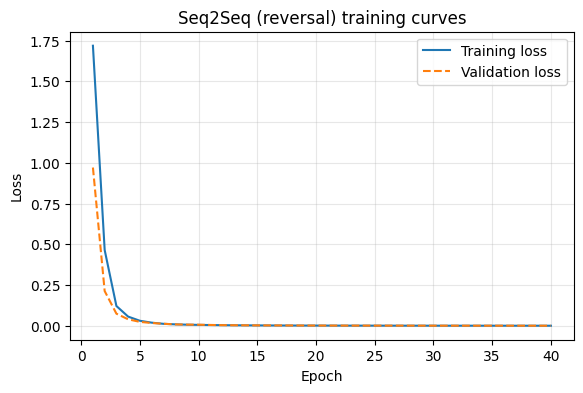

,Value
Token accuracy (%),100.0000
Sequence accuracy (%),100.0000
Training loss,0.0002
Validation loss,0.0002
Test loss (teacher forcing),0.0003
Parameters,166794.0000


--- Inference (token vs. sequence accuracy) ---
Token accuracy = 100.00% but sequence accuracy = 100.00%.
A sequence is correct only if ALL 6 tokens are correct; if errors were independent, sequence accuracy ~ p^L = 1.0000^6 = 100.00%.
Also, one wrong token in greedy decoding is fed back to the decoder and can corrupt later tokens (error propagation),
so sequence-level accuracy is always <= token-level accuracy and drops quickly as sequences get longer.


In [18]:
V = 10   # 0 = START, 1..9 = digits

def build_seq2seq(in_len, out_len, V=V, emb=32, units=128):
    enc_in = keras.Input((in_len,), name="enc_in")
    e = layers.Embedding(V, emb)(enc_in)
    _, h, c = layers.LSTM(units, return_state=True, name="enc_lstm")(e)             # context state
    dec_in = keras.Input((out_len,), name="dec_in")
    dec_emb = layers.Embedding(V, emb, name="dec_emb")
    dec_lstm = layers.LSTM(units, return_sequences=True, return_state=True, name="dec_lstm")
    dense = layers.Dense(V, activation="softmax", name="dec_out")
    d, _, _ = dec_lstm(dec_emb(dec_in), initial_state=[h, c])
    train_model = keras.Model([enc_in, dec_in], dense(d))
    enc_model = keras.Model(enc_in, [h, c])
    # one-step decoder used for inference
    s_tok = keras.Input((1,)); s_h = keras.Input((units,)); s_c = keras.Input((units,))
    sd, nh, nc = dec_lstm(dec_emb(s_tok), initial_state=[s_h, s_c])
    dec_model = keras.Model([s_tok, s_h, s_c], [dense(sd), nh, nc])
    train_model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return train_model, enc_model, dec_model

def greedy_decode(enc_model, dec_model, X, out_len):
    h, c = enc_model.predict(X, verbose=0)
    tok = np.zeros((len(X), 1), dtype="int32"); outs = []
    for _ in range(out_len):
        p, h, c = dec_model.predict([tok, h, c], verbose=0)
        tok = p[:, 0, :].argmax(-1)[:, None].astype("int32"); outs.append(tok[:, 0])
    return np.stack(outs, 1)

def run_seq2seq(in_len=6, out_len=6, fn=lambda s: s[::-1], n=12000, epochs=40, units=128, tag="reversal", verbose_examples=True):
    set_seed()
    X = np.random.randint(1, V, size=(n, in_len)).astype("int32")
    Y = np.array([fn(s) for s in X]).astype("int32"); assert Y.shape[1] == out_len
    Din = np.concatenate([np.zeros((n, 1), "int32"), Y[:, :-1]], axis=1)              # teacher-forcing decoder input
    idx = np.arange(n)
    tr, tmp = train_test_split(idx, test_size=0.30, random_state=SEED); va, te = train_test_split(tmp, test_size=0.50, random_state=SEED)
    model, enc_m, dec_m = build_seq2seq(in_len, out_len, units=units)
    t0 = time.perf_counter()
    hist = model.fit([X[tr], Din[tr]], Y[tr], validation_data=([X[va], Din[va]], Y[va]),
                     epochs=epochs, batch_size=64, verbose=0, callbacks=[Every(10)])
    tt = time.perf_counter() - t0
    test_loss, _ = model.evaluate([X[te], Din[te]], Y[te], verbose=0)
    pred = greedy_decode(enc_m, dec_m, X[te], out_len)
    tok_acc = (pred == Y[te]).mean(); seq_acc = (pred == Y[te]).all(1).mean()
    out = dict(model=model, hist=hist.history, tok_acc=100 * tok_acc, seq_acc=100 * seq_acc,
               train_loss=hist.history["loss"][-1], val_loss=hist.history["val_loss"][-1], test_loss=test_loss,
               params=n_trainable(model), time=tt, X=X[te], Y=Y[te], pred=pred, out_len=out_len)
    print(f"\n[{tag}] token accuracy {out['tok_acc']:.2f}% | sequence accuracy {out['seq_acc']:.2f}% | "
          f"train loss {out['train_loss']:.4f} | val loss {out['val_loss']:.4f} | test loss {test_loss:.4f}")
    if verbose_examples:
        ex = pd.DataFrame({"Sample": range(1, 8),
                           "Input Sequence": [str(list(a)) for a in X[te][:7]],
                           "True Output": [str(list(a)) for a in Y[te][:7]],
                           "Predicted Output": [str(list(a)) for a in pred[:7]],
                           "Correct": ["yes" if (a == b).all() else "no" for a, b in zip(pred[:7], Y[te][:7])]}).set_index("Sample")
        display(ex)
    return out

S2S = run_seq2seq()
h = S2S["hist"]; ep = np.arange(1, len(h["loss"]) + 1)
plt.figure(figsize=(6.5, 4)); plt.plot(ep, h["loss"], label="Training loss"); plt.plot(ep, h["val_loss"], "--", label="Validation loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Seq2Seq (reversal) training curves"); plt.grid(alpha=.3); plt.legend()
save_fig("seq2seq_curves"); plt.show()

s2s_table = pd.DataFrame({"Value": {"Token accuracy (%)": S2S["tok_acc"], "Sequence accuracy (%)": S2S["seq_acc"],
                                    "Training loss": S2S["train_loss"], "Validation loss": S2S["val_loss"],
                                    "Test loss (teacher forcing)": S2S["test_loss"], "Parameters": S2S["params"]}})
display(s2s_table.round(4))

p = S2S["tok_acc"] / 100
print("--- Inference (token vs. sequence accuracy) ---")
print(f"Token accuracy = {S2S['tok_acc']:.2f}% but sequence accuracy = {S2S['seq_acc']:.2f}%.")
print(f"A sequence is correct only if ALL {S2S['out_len']} tokens are correct; if errors were independent, sequence accuracy ~ p^L = {p:.4f}^{S2S['out_len']} = {100*p**S2S['out_len']:.2f}%.")
print("Also, one wrong token in greedy decoding is fed back to the decoder and can corrupt later tokens (error propagation),")
print("so sequence-level accuracy is always <= token-level accuracy and drops quickly as sequences get longer.")

## 25. Consolidated Results

In [19]:
cons = pd.DataFrame({
    "Accuracy (%)":  [R[c]["acc"]  for c in ["rnn", "lstm", "gru"]] + [VR[v_sel]["acc"]],
    "Precision (%)": [R[c]["prec"] for c in ["rnn", "lstm", "gru"]] + [VR[v_sel]["prec"]],
    "Recall (%)":    [R[c]["rec"]  for c in ["rnn", "lstm", "gru"]] + [VR[v_sel]["rec"]],
    "F1 (%)":        [R[c]["f1"]   for c in ["rnn", "lstm", "gru"]] + [VR[v_sel]["f1"]],
    "Parameters":    [R[c]["params"] for c in ["rnn", "lstm", "gru"]] + [VR[v_sel]["params"]]},
    index=["RNN", "LSTM", "GRU", f"CNN-{PRETTY[v_sel]}"])
print("Table 1 - Classification tasks (HAR: RNN/LSTM/GRU on sensor sequences; CNN-RNN on UCF101 videos)")
display(cons.round(2)); cons.round(4).to_csv("table_consolidated.csv")

print("\nTable 2 - Sequence-to-sequence task")
display(s2s_table.round(4)); s2s_table.round(4).to_csv("table_seq2seq.csv")

Table 1 - Classification tasks (HAR: RNN/LSTM/GRU on sensor sequences; CNN-RNN on UCF101 videos)


,Accuracy (%),Precision (%),Recall (%),F1 (%),Parameters
RNN,81.11,82.47,80.30,80.43,1974
LSTM,90.89,91.54,91.11,91.13,6006
GRU,94.89,95.37,95.14,95.18,4758
CNN-LSTM,74.12,74.11,74.17,73.02,168677



Table 2 - Sequence-to-sequence task


,Value
Token accuracy (%),100.0000
Sequence accuracy (%),100.0000
Training loss,0.0002
Validation loss,0.0002
Test loss (teacher forcing),0.0003
Parameters,166794.0000


## 28. Additional Exercises
1. 16 / 32 / 64 units · 2. GRU vs LSTM at equal units (same table) · 3. stacked (2-layer) recurrent models · 4. BiLSTM vs LSTM · 5. Sequence length vs. cost (already in Section 17) · 6. Video LSTM vs GRU (already in Section 18–21) · 7. Seq2Seq with different output length.
Set `RUN_EXTRA = False` in the first cell to skip the heavy ones.


>>> RNN with 16 units
   epoch   1 | loss 1.7652 acc 0.2919 | val_loss 1.5622 val_acc 0.4200
   epoch  10 | loss 0.8457 acc 0.6162 | val_loss 0.8099 val_acc 0.6311
   epoch  20 | loss 0.6886 acc 0.6724 | val_loss 0.6830 val_acc 0.6600
   epoch  30 | loss 0.6574 acc 0.6967 | val_loss 0.6464 val_acc 0.7244

>>> LSTM with 16 units
   epoch   1 | loss 1.6689 acc 0.3743 | val_loss 1.4933 val_acc 0.4489
   epoch  10 | loss 0.4357 acc 0.8157 | val_loss 0.4189 val_acc 0.8289
   epoch  20 | loss 0.2795 acc 0.9029 | val_loss 0.2330 val_acc 0.9267
   epoch  30 | loss 0.2115 acc 0.9281 | val_loss 0.2106 val_acc 0.9311

>>> GRU with 16 units
   epoch   1 | loss 1.7434 acc 0.2900 | val_loss 1.5794 val_acc 0.4467
   epoch  10 | loss 0.4790 acc 0.8157 | val_loss 0.4138 val_acc 0.8444
   epoch  20 | loss 0.2079 acc 0.9367 | val_loss 0.1600 val_acc 0.9400
   epoch  30 | loss 0.1587 acc 0.9438 | val_loss 0.1295 val_acc 0.9467

>>> RNN with 64 units
   epoch   1 | loss 1.3915 acc 0.4733 | val_loss 1.0910

,Model,Units,Accuracy (%),Macro F1 (%),Parameters,Training Time (s)
0,RNN,16,68.00,65.87,790,48.42
1,RNN,32,81.11,80.43,1974,48.68
2,RNN,64,82.67,82.05,5878,65.12
3,LSTM,16,92.67,92.80,2038,98.20
4,LSTM,32,90.89,91.13,6006,96.26
5,LSTM,64,95.11,95.38,20086,138.25
6,GRU,16,94.44,94.66,1670,151.14
7,GRU,32,94.89,95.18,4758,144.64
8,GRU,64,94.67,94.98,15542,170.23


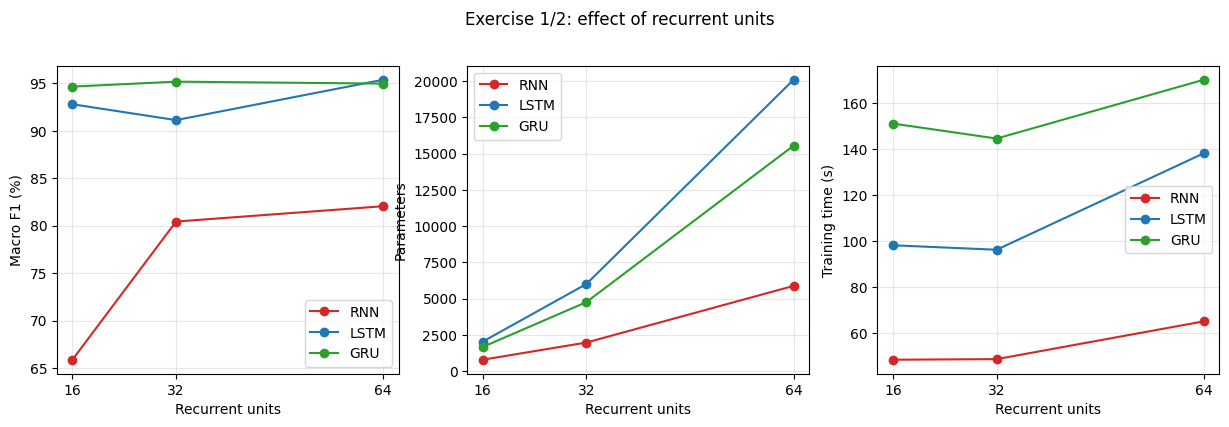

GRU vs LSTM at equal units (Macro F1 %):


Model,GRU,LSTM,RNN
Units,,,
16,94.66,92.80,65.87
32,95.18,91.13,80.43
64,94.98,95.38,82.05


In [20]:
if RUN_EXTRA:
    # ---- Exercise 1 & 2: number of recurrent units (16 / 32 / 64) for all three models ----
    UNIT_LIST = [16, 32, 64]
    EX1 = {}
    for u in UNIT_LIST:
        for c in ["rnn", "lstm", "gru"]:
            if u == UNITS: EX1[(c, u)] = R[c]; continue
            print(f"\n>>> {PRETTY[c]} with {u} units")
            EX1[(c, u)] = train_eval(c, DATA, units=u)
    rows = [{"Model": PRETTY[c], "Units": u, "Accuracy (%)": EX1[(c, u)]["acc"], "Macro F1 (%)": EX1[(c, u)]["f1"],
             "Parameters": EX1[(c, u)]["params"], "Training Time (s)": EX1[(c, u)]["time"]}
            for c in ["rnn", "lstm", "gru"] for u in UNIT_LIST]
    ex1 = pd.DataFrame(rows); display(ex1.round(2))
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    for c in ["rnn", "lstm", "gru"]:
        for a, key, lab in zip(ax, ["Macro F1 (%)", "Parameters", "Training Time (s)"], ["Macro F1 (%)", "Parameters", "Training time (s)"]):
            a.plot(UNIT_LIST, ex1[ex1.Model == PRETTY[c]][key], marker="o", label=PRETTY[c], color=COLORS[c]); a.set_ylabel(lab)
    for a in ax: a.set_xlabel("Recurrent units"); a.set_xticks(UNIT_LIST); a.grid(alpha=.3); a.legend()
    fig.suptitle("Exercise 1/2: effect of recurrent units", y=1.02); save_fig("ex1_units"); plt.show()
    print("GRU vs LSTM at equal units (Macro F1 %):")
    display(ex1.pivot(index="Units", columns="Model", values="Macro F1 (%)").round(2))

In [21]:
if RUN_EXTRA:
    # ---- Exercise 3: second recurrent layer ----
    EX3 = {}
    for c in ["rnn", "lstm", "gru"]:
        print(f"\n>>> Stacked 2-layer {PRETTY[c]}")
        EX3[c] = train_eval(c, DATA, n_layers=2)
    ex3 = pd.DataFrame({"Model": [PRETTY[c] for c in EX3],
                        "1-layer F1 (%)": [R[c]["f1"] for c in EX3], "2-layer F1 (%)": [EX3[c]["f1"] for c in EX3],
                        "1-layer params": [R[c]["params"] for c in EX3], "2-layer params": [EX3[c]["params"] for c in EX3],
                        "1-layer time (s)": [R[c]["time"] for c in EX3], "2-layer time (s)": [EX3[c]["time"] for c in EX3]}).set_index("Model")
    print("Exercise 3: does a second recurrent layer help?"); display(ex3.round(2))

    # ---- Exercise 4: bidirectional LSTM vs unidirectional LSTM ----
    print("\n>>> Bidirectional LSTM")
    BI = train_eval("lstm", DATA, bidirectional=True)
    ex4 = pd.DataFrame({"LSTM (uni)": {"Accuracy (%)": R["lstm"]["acc"], "Macro F1 (%)": R["lstm"]["f1"], "Parameters": R["lstm"]["params"], "Training Time (s)": R["lstm"]["time"]},
                        "BiLSTM":     {"Accuracy (%)": BI["acc"], "Macro F1 (%)": BI["f1"], "Parameters": BI["params"], "Training Time (s)": BI["time"]}})
    print("Exercise 4: BiLSTM vs LSTM"); display(ex4.round(2))

    # ---- Exercise 7: seq2seq with a different output length (output = first 3 elements of the reversed input) ----
    print("\n>>> Exercise 7: seq2seq, input length 6 -> output length 3")
    S2S_var = run_seq2seq(in_len=6, out_len=3, fn=lambda s: s[::-1][:3], tag="reverse-and-truncate (6 -> 3)")


>>> Stacked 2-layer RNN
   epoch   1 | loss 1.3752 acc 0.5105 | val_loss 1.0050 val_acc 0.6133
   epoch  10 | loss 0.5394 acc 0.7681 | val_loss 0.5647 val_acc 0.7333
   epoch  20 | loss 0.4159 acc 0.8305 | val_loss 0.4211 val_acc 0.8400
   epoch  30 | loss 0.5457 acc 0.7486 | val_loss 0.6355 val_acc 0.7200

>>> Stacked 2-layer LSTM
   epoch   1 | loss 1.4530 acc 0.4300 | val_loss 1.0469 val_acc 0.6178
   epoch  10 | loss 0.1579 acc 0.9400 | val_loss 0.1220 val_acc 0.9578
   epoch  20 | loss 0.1366 acc 0.9524 | val_loss 0.1670 val_acc 0.9444
   epoch  30 | loss 0.1099 acc 0.9576 | val_loss 0.1166 val_acc 0.9578

>>> Stacked 2-layer GRU
   epoch   1 | loss 1.5233 acc 0.3719 | val_loss 1.2451 val_acc 0.5422
   epoch  10 | loss 0.1673 acc 0.9405 | val_loss 0.1534 val_acc 0.9444
   epoch  20 | loss 0.1240 acc 0.9519 | val_loss 0.1251 val_acc 0.9467
   epoch  30 | loss 0.1153 acc 0.9529 | val_loss 0.1237 val_acc 0.9467
Exercise 3: does a second recurrent layer help?


,1-layer F1 (%),2-layer F1 (%),1-layer params,2-layer params,1-layer time (s),2-layer time (s)
Model,,,,,,
RNN,80.43,67.76,1974,4054,48.68,122.06
LSTM,91.13,95.18,6006,14326,96.26,308.83
GRU,95.18,95.61,4758,11094,144.64,254.69



>>> Bidirectional LSTM
   epoch   1 | loss 1.5203 acc 0.4086 | val_loss 1.0983 val_acc 0.6022
   epoch  10 | loss 0.3135 acc 0.8867 | val_loss 0.3042 val_acc 0.9067
   epoch  20 | loss 0.1408 acc 0.9462 | val_loss 0.1335 val_acc 0.9489
   epoch  30 | loss 0.1175 acc 0.9548 | val_loss 0.1293 val_acc 0.9489
Exercise 4: BiLSTM vs LSTM


,LSTM (uni),BiLSTM
Accuracy (%),90.89,94.89
Macro F1 (%),91.13,95.18
Parameters,6006.00,11894.00
Training Time (s),96.26,103.91



>>> Exercise 7: seq2seq, input length 6 -> output length 3
   epoch   1 | loss 1.6347 acc 0.3879 | val_loss 0.8361 val_acc 0.6859
   epoch  10 | loss 0.0016 acc 1.0000 | val_loss 0.0015 val_acc 1.0000
   epoch  20 | loss 0.0004 acc 1.0000 | val_loss 0.0004 val_acc 1.0000
   epoch  30 | loss 0.0001 acc 1.0000 | val_loss 0.0001 val_acc 1.0000
   epoch  40 | loss 0.0001 acc 1.0000 | val_loss 0.0001 val_acc 1.0000

[reverse-and-truncate (6 -> 3)] token accuracy 100.00% | sequence accuracy 100.00% | train loss 0.0001 | val loss 0.0001 | test loss 0.0001


,Input Sequence,True Output,Predicted Output,Correct
Sample,,,,
1,"[np.int32(2), np.int32(8), np.int32(9), np.int...","[np.int32(2), np.int32(7), np.int32(8)]","[np.int32(2), np.int32(7), np.int32(8)]",yes
2,"[np.int32(7), np.int32(9), np.int32(1), np.int...","[np.int32(9), np.int32(9), np.int32(8)]","[np.int32(9), np.int32(9), np.int32(8)]",yes
3,"[np.int32(9), np.int32(1), np.int32(1), np.int...","[np.int32(4), np.int32(1), np.int32(5)]","[np.int32(4), np.int32(1), np.int32(5)]",yes
4,"[np.int32(7), np.int32(3), np.int32(7), np.int...","[np.int32(5), np.int32(6), np.int32(4)]","[np.int32(5), np.int32(6), np.int32(4)]",yes
5,"[np.int32(7), np.int32(2), np.int32(2), np.int...","[np.int32(7), np.int32(4), np.int32(5)]","[np.int32(7), np.int32(4), np.int32(5)]",yes
6,"[np.int32(5), np.int32(8), np.int32(8), np.int...","[np.int32(9), np.int32(8), np.int32(5)]","[np.int32(9), np.int32(8), np.int32(5)]",yes
7,"[np.int32(6), np.int32(9), np.int32(3), np.int...","[np.int32(9), np.int32(9), np.int32(7)]","[np.int32(9), np.int32(9), np.int32(7)]",yes


## 26. Required Inferences – how to write them in your report
For **every plot** answer: **(1) What does it show? (2) What trend? (3) Why? (4) Conclusion?** The cells above already print the *measured facts* for each of these – copy the numbers into your sentences:

| Mandatory inference | Where the numbers come from |
|---|---|
| Temporal pattern of sensor signals | Plot 1 + stats table + printed inference |
| Convergence of RNN / LSTM / GRU | Plots 2–3 + `diagnose()` output (best-val epoch, epoch to 90 %, final gap) |
| Over-/under-fitting | `diagnose()` verdicts, generalisation gap |
| Activity-wise errors | Plot 4 + `analyze_cm()` output |
| Effect of sequence length | Plot 6 + F1 / time tables |
| Parameter & computational differences | Section 16 table (parameter ratios, time ratios) |
| Role of CNN in video | Plot 7 – spatial features per frame (edges → objects → scene), frozen ImageNet weights, D = 1280 |
| Role of recurrent model in video | Plot 8/9 – learns order/motion across the 10 feature vectors; CNN alone sees single frames |
| Token vs. sequence accuracy | Seq2Seq inference cell (p^L argument + error propagation) |

**Generic wording template:** *"Plot X shows … Over epochs, … (trend, with numbers). This happens because … (e.g. gates keep gradients alive / small data / static classes have similar gravity vectors). Hence …"*

**Expected qualitative outcomes (verify against YOUR numbers, do not copy blindly):** the gated models (LSTM/GRU) usually converge faster and more smoothly than SimpleRNN; static activities (SITTING vs STANDING) are the classic confusion pair while LAYING is easy; more time steps generally help; GRU ≈ LSTM accuracy with fewer parameters.

## 27. Discussion Questions – Answers
1. **RNN:** a network with a feedback (recurrent) connection that processes a sequence one step at a time, re-using the same weights and carrying a hidden state.
2. **Hidden state:** a compressed summary/memory of everything seen so far (x₁ … x_t) that is used to produce the output and the next state.
3. **Order matters:** the meaning of a sequence depends on the order of its elements (a gait cycle, a sentence); shuffling changes or destroys the pattern.
4. **FFN vs RNN:** an FFN maps a fixed-size input to an output with no memory and no weight sharing across positions; an RNN has a recurrent loop, keeps state, shares weights over time and handles variable-length input.
5. **BPTT:** unroll the RNN over T steps into a deep feed-forward graph with shared weights and back-propagate through it; the gradient of each shared weight is the sum of its contributions at every time step.
6. **Vanishing gradients:** ∂h_t/∂h_{t−1} = diag(1−h_t²)·W_h; when its norm is < 1 (tanh derivative ≤ 1, small W_h), the product over many steps shrinks exponentially.
7. **Exploding gradients:** when the norm of that Jacobian is > 1 (spectral radius of W_h > 1) the product grows exponentially; mitigated by gradient clipping, careful/orthogonal initialisation.
8. **Long-term dependencies:** cases where the output at time t depends on inputs many steps earlier.
9. **LSTM cell state:** a separate memory line updated additively (C_t = f_t·C_{t−1} + i_t·C̃_t), giving gradients a near-linear path through time.
10. **LSTM gates:** *forget* – how much old cell state to keep; *input* – how much new candidate information to write; *output* – how much of the cell state to expose as h_t.
11. **GRU gates:** *reset* – how much of the previous state is used to compute the candidate; *update* – interpolation between the old state and the candidate.
12. **LSTM vs GRU:** LSTM has 3 gates + separate cell state (4 weight blocks); GRU has 2 gates, no separate cell state (3 blocks) → ~25 % fewer parameters and slightly faster, often similar accuracy; LSTM can be better on very long/complex dependencies.
13. **Why GRU is simpler:** it merges cell and hidden state, ties forget and input into one update gate (z and 1−z) and drops the output gate.
14. **Same settings for all:** a controlled experiment – any difference in results can then be attributed to the architecture and not to data, optimiser, epochs, etc.
15. **Confusion matrix:** shows *which* classes are confused and per-class recall/precision, revealing errors hidden by overall accuracy (e.g. SITTING ↔ STANDING).
16. **Macro-F1:** averages F1 over classes with equal weight, so minority classes count as much as majority ones and both precision and recall are combined.
17. **Sequence length:** it sets the amount of temporal context; longer sequences carry more information but cost more compute and make gradient flow harder.
18. **CNN for video:** a pretrained CNN gives compact, generic spatial features, is cheap (no training) and reduces over-fitting on small video sets.
19. **CNN extracts:** spatial content of each frame – edges, textures, shapes, objects, scene layout, pose.
20. **RNN learns:** temporal dynamics – motion, order of events and how features change across frames.
21. **Why a sequence of CNN features:** a video is an ordered set of frames; stacking the per-frame vectors as (T, D) gives the recurrent net a time axis to model.
22. **Encoder/decoder:** the encoder reads the input sequence and compresses it into a context state (h, c); the decoder is initialised with that context and generates the output sequence token by token.
23. **Teacher forcing:** during training the decoder receives the ground-truth previous token instead of its own prediction – faster, more stable training, but causes exposure bias at inference.
24. **Token vs sequence accuracy:** token accuracy = correct tokens / all tokens; sequence accuracy = fully correct sequences / all sequences (≈ p^L if independent), so it is always ≤ token accuracy.
25. **Untouched test set:** to get an unbiased estimate of generalisation; using it for model selection leaks information and gives over-optimistic results.

## Save / download everything
Zips all figures and CSV tables for inclusion in the report.

In [22]:
shutil.make_archive("experiment6_outputs", "zip", "figures")
for f in ["table_metrics_har.csv", "table_consolidated.csv", "table_seq2seq.csv"]:
    if os.path.exists(f): shutil.copy(f, "figures/")
shutil.make_archive("experiment6_outputs", "zip", "figures")
try:
    from google.colab import files
    files.download("experiment6_outputs.zip")
except Exception as e:
    print("Download manually from the file browser:", e)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>